# OU process - Work sheet - Pridict $\epsilon_\theta$
## OU process basic information
可以參考 *OU process -預測score到noise* 這篇筆記
參考檔案: OU_train_epsilon-2D BolbLine
以參考檔案作修改,使得beta選取為const...

# Model

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # 建議用 GPU

batch_size = 2048

def sample_line(n_points):
    slope = 0.4
    intercept = -5.0
    x = np.random.uniform(-6, 6, size=n_points)
    noise = np.random.randn(n_points) * 0.2   
    y = slope * x + intercept + noise
    return np.stack([x, y], axis=1)

def sample_blob(n_points):
    mu = np.array([-5, 0])
    C = np.eye(2) * 1.0
    return mu + np.random.multivariate_normal([0,0], C, size=n_points)

def sample_p0_mix(n_blob=3000, n_line=2000):
    blob = sample_blob(n_blob)
    line = sample_line(n_line)
    data = np.concatenate([blob, line], axis=0)
    np.random.shuffle(data)
    return data

def marginal_prob_std(t, beta=10.0): # 把 beta 為常數
    log_mean_coeff = -0.5 * t * beta
    mean = torch.exp(log_mean_coeff)
    std = torch.sqrt(1. - torch.exp(2. * log_mean_coeff))
    return mean, std


In [8]:
class ScoreNet_SDE(nn.Module):
    def __init__(self, x_dim, hidden):
        super().__init__()
        
        self.embed = nn.Sequential(
            nn.Linear(1, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU()
        )
        
        self.fc1 = nn.Linear(x_dim, hidden)
        self.layers = nn.ModuleList()
        for _ in range(3):
            self.layers.append(nn.Linear(hidden, hidden))
        self.fc_out = nn.Linear(hidden, x_dim)
        self.act = nn.SiLU()

    def forward(self, x, t):
        if t.dim() == 1:
            t = t.unsqueeze(-1) 
            
        t_embed = self.embed(t)
        
        h = self.fc1(x)
        h = h + t_embed
        h = self.act(h)  ## SiLU
        for layer in self.layers:
            h = self.act(layer(h)) 
        
        # Output: noise
        return self.fc_out(h)

def sde_dsm_loss(model, x0):
    batch_size = x0.shape[0]
    num_steps = 2048  

    t_discrete = torch.linspace(1e-5, 1.0, num_steps, device=x0.device)
    random_indices = torch.randint(0, num_steps, (batch_size,), device=x0.device)
    t = t_discrete[random_indices]
    
    mean, std = marginal_prob_std(t)
    mean = mean.view(-1, 1)
    std = std.view(-1, 1)
    
    noise = torch.randn_like(x0) 
    xt = mean * x0 + std * noise
    noise_pred = model(xt, t)
    
    loss = torch.mean(torch.sum((noise_pred - noise)**2, dim=1))
    return loss

In [9]:
# =========== Training Loop ===========
model = ScoreNet_SDE(x_dim=2, hidden=128).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Start SDE Training...")
n_step = 5000
loss_history = []

for step in range(1, n_step+1):
    x0_np = sample_p0_mix(batch_size//2, batch_size - batch_size//2).astype(np.float32)
    x0 = torch.from_numpy(x0_np).to(device)
    
    model.train()
    loss = sde_dsm_loss(model, x0)
    
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    
    loss_history.append(loss.item())
    if step % 500 == 0:
        print(f"Step {step:4d} | Loss: {loss.item():.6f}")


Start SDE Training...
Step  500 | Loss: 0.368328
Step 1000 | Loss: 0.383130
Step 1500 | Loss: 0.365143
Step 2000 | Loss: 0.334574
Step 2500 | Loss: 0.381297
Step 3000 | Loss: 0.395055
Step 3500 | Loss: 0.363379
Step 4000 | Loss: 0.371762
Step 4500 | Loss: 0.377379
Step 5000 | Loss: 0.406034


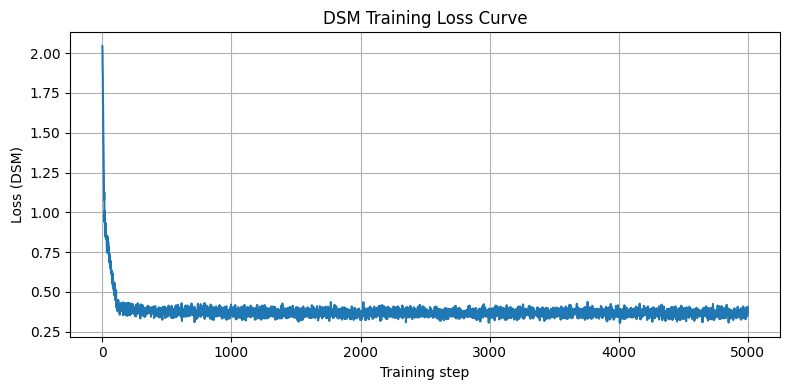

In [10]:
import matplotlib.pyplot as plt

def plot_loss_curve(loss_list):
    """
    loss_list: Python list or Tensor containing loss values for each step
    """
    plt.figure(figsize=(8,4))
    plt.plot(loss_list, linewidth=1.5)
    plt.xlabel("Training step")
    plt.ylabel("Loss (DSM)")
    plt.title("DSM Training Loss Curve")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_loss_curve(loss_history)

# Reverse Sample